# Practical 3: Latent Factor Models (Matrix Factorization)

In this practical, we implement a **Latent Factor Model** (Matrix Factorization) using **Alternating Least Squares (ALS)**.

We model the rating $r_{mn}$ as:
$$ r_{mn} \approx \mu + b_m + b_n + \mathbf{u}_m^T \mathbf{v}_n $$

Where:
- $\mu$ is the global mean
- $b_m$ is the user bias
- $b_n$ is the item bias
- $\mathbf{u}_m \in \mathbb{R}^K$ is the user latent vector
- $\mathbf{v}_n \in \mathbb{R}^K$ is the item latent vector

We will explore the effect of the latent dimension $K$ on model performance.

In [9]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add project root to path for imports
import sys
sys.path.append('..')

from src.data_loader import download_dataset, MovieLensDataset
from src.data_structures import RatingMatrix
from src.train_test_split import random_split
from src.als import MatrixFactorizationModel
from src.metrics import compute_rmse

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load Data

We use the **MovieLens Small** dataset (100k ratings).

In [10]:
# Download and load dataset
data_path = download_dataset("ml-latest-small", data_dir="../data")
dataset = MovieLensDataset(data_path)

print(dataset.summary())

Dataset already exists at ..\data\ml-latest-small
Loading ratings from ..\data\ml-latest-small\ratings.csv...
Loaded 100,836 ratings
MovieLens Dataset Summary
Users:              610
Items:            9,724
Ratings:        100,836
Sparsity:      98.3000%
Mean:             3.502



## 2. Prepare Data

We split the data using a **time-based split** (last 20% of ratings per user for testing).

In [11]:
user_idx, item_idx, ratings = dataset.get_arrays()
timestamps = dataset.ratings['timestamp'].values

train_data, test_data = random_split(
    user_idx, item_idx, ratings, test_ratio=0.2
)

print(f"Train size: {len(train_data[2]):,}")
print(f"Test size:  {len(test_data[2]):,}")

Train size: 80,668
Test size:  20,168


In [12]:
# Build RatingMatrix from training data
train_matrix = RatingMatrix(
    train_data[0], train_data[1], train_data[2],
    n_users=dataset.n_users, n_items=dataset.n_items
)

print(train_matrix)

RatingMatrix(users=610, items=9,724, ratings=80,668, sparsity=98.6400%)


## 3. Train Models

We train Matrix Factorization models with different latent dimensions $K \in \{5, 10, 20\}$.

In [13]:
K_values = [5, 10, 20]
models = {}
results = {}

for K in K_values:
    print(f"\nTraining model with K={K}...")
    model = MatrixFactorizationModel(
        K=K, 
        lambda_=0.1,    # Regularization
        tau=1.0,        # Precision (weight)
        gamma=0.1,      # Bias regularization
        n_iters=15,
        verbose=True
    )
    
    model.fit(train_matrix, test_data=test_data)
    
    model.save(f"../models/als_k{K}.npz")
    models[K] = model
    results[K] = {
        'train_rmse': model.train_rmse_history,
        'test_rmse': model.test_rmse_history
    }


Training model with K=5...
Iter 1: Loss=2722.92, Train RMSE=0.8005, Test RMSE=0.8788 (16.15s)
Iter 2: Loss=2533.38, Train RMSE=0.7479, Test RMSE=0.8651 (0.00s)
Iter 3: Loss=2441.22, Train RMSE=0.7111, Test RMSE=0.8665 (0.00s)
Iter 4: Loss=2412.72, Train RMSE=0.6991, Test RMSE=0.8662 (0.00s)
Iter 5: Loss=2399.89, Train RMSE=0.6939, Test RMSE=0.8653 (0.00s)
Iter 6: Loss=2392.46, Train RMSE=0.6910, Test RMSE=0.8643 (0.00s)
Iter 7: Loss=2387.43, Train RMSE=0.6892, Test RMSE=0.8634 (0.00s)
Iter 8: Loss=2383.69, Train RMSE=0.6880, Test RMSE=0.8625 (0.00s)
Iter 9: Loss=2380.75, Train RMSE=0.6870, Test RMSE=0.8616 (0.00s)
Iter 10: Loss=2378.38, Train RMSE=0.6863, Test RMSE=0.8607 (0.00s)
Iter 11: Loss=2376.41, Train RMSE=0.6857, Test RMSE=0.8599 (0.00s)
Iter 12: Loss=2374.78, Train RMSE=0.6853, Test RMSE=0.8592 (0.00s)
Iter 13: Loss=2373.39, Train RMSE=0.6849, Test RMSE=0.8585 (0.00s)
Iter 14: Loss=2372.23, Train RMSE=0.6845, Test RMSE=0.8579 (0.00s)
Iter 15: Loss=2371.24, Train RMSE=0.6843, 

## 4. Evaluation

We compare the learning curves for different $K$.

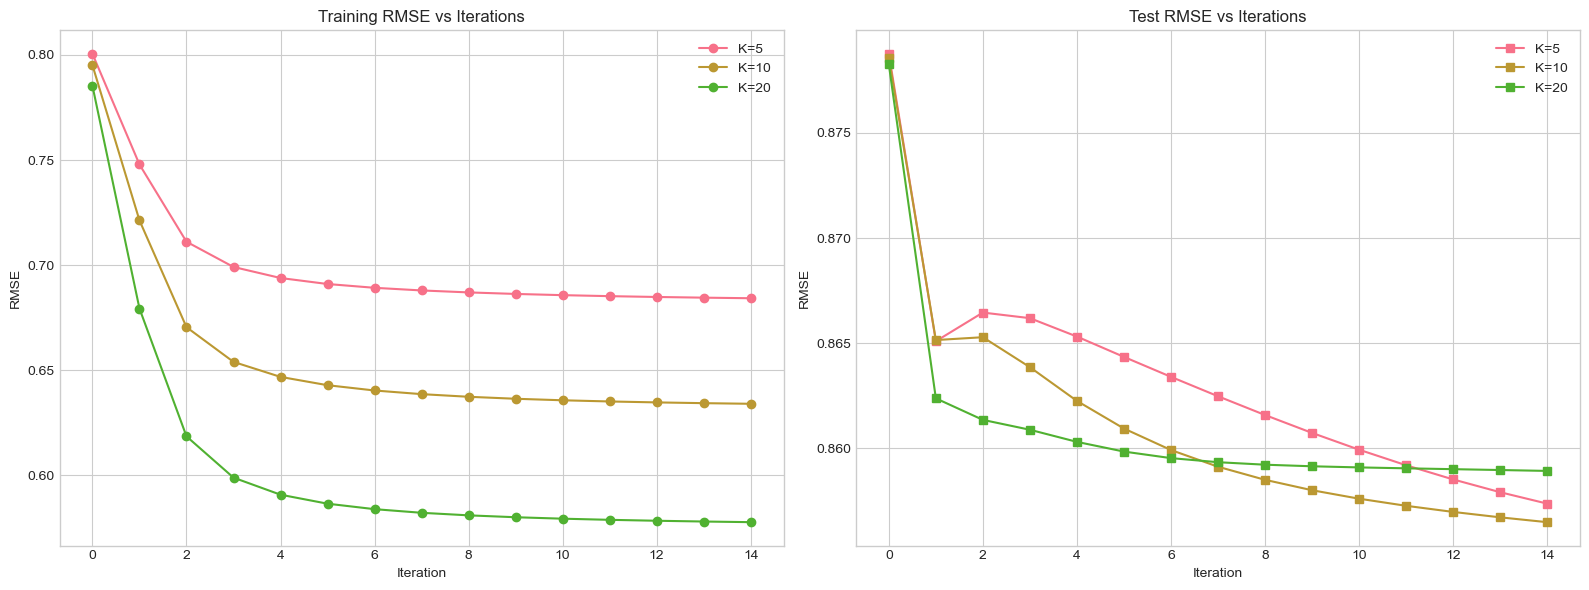

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Train RMSE
ax = axes[0]
for K, res in results.items():
    ax.plot(res['train_rmse'], marker='o', label=f'K={K}')
ax.set_title("Training RMSE vs Iterations")
ax.set_xlabel("Iteration")
ax.set_ylabel("RMSE")
ax.legend()

# Plot Test RMSE
ax = axes[1]
for K, res in results.items():
    ax.plot(res['test_rmse'], marker='s', label=f'K={K}')
ax.set_title("Test RMSE vs Iterations")
ax.set_xlabel("Iteration")
ax.set_ylabel("RMSE")
ax.legend()

plt.tight_layout()
plt.savefig('../figures/practical_3_rmse.pdf', format='pdf')
plt.show()

## 5. Visualizing Embeddings

We visualize the learned item embeddings for $K=20$. We use PCA to project them to 2D.

Visualizing 450 popular movies.
Loading movies from ..\data\ml-latest-small\movies.csv...
Loaded 9,742 movies


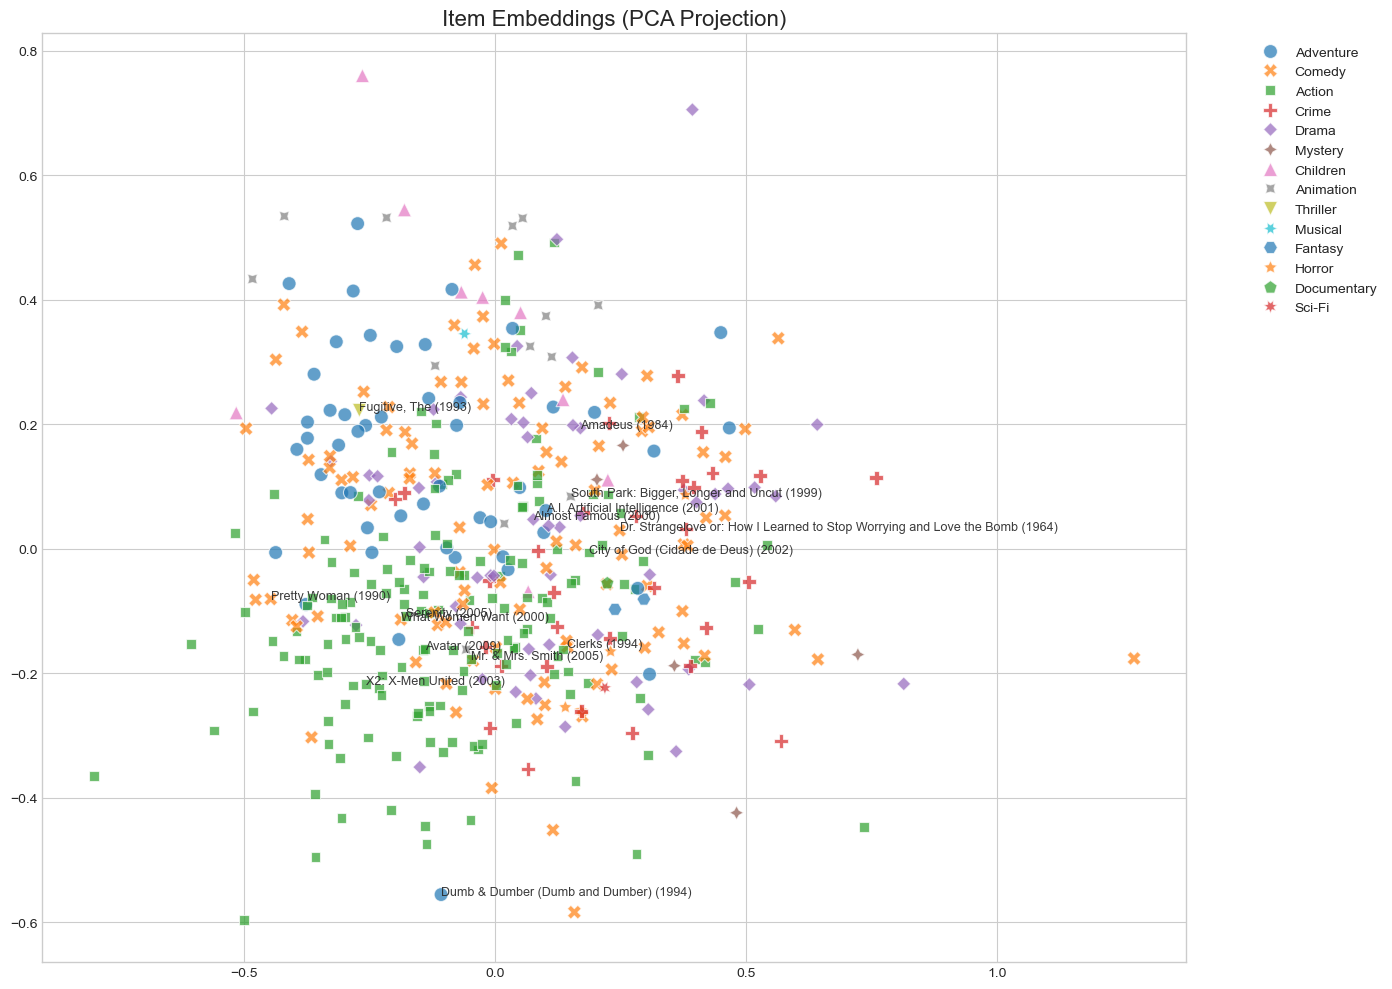

In [15]:
from sklearn.decomposition import PCA

# Get items with at least 50 ratings for cleaner visualization
item_counts = dataset.get_item_counts()
popular_items = np.where(item_counts >= 50)[0]
print(f"Visualizing {len(popular_items)} popular movies.")

model_best = models[20]
vectors = model_best.item_factors[popular_items]
titles = []
genres = []

# Map indices back to movie titles/genres
# Note: dataset.movies uses original ID, we need to map internal idx -> original ID
# dataset._item_id_map maps Original -> Internal
# We invert it: Internal -> Original

inv_map = {v: k for k, v in dataset._item_id_map.items()}

for idx in popular_items:
    orig_id = inv_map[idx]
    # Pandas lookup
    row = dataset.movies[dataset.movies['movieId'] == orig_id]
    if not row.empty:
        titles.append(row['title'].values[0])
        # Take first genre for coloring
        g_full = row['genres'].values[0]
        g_first = g_full.split('|')[0]
        genres.append(g_first)
    else:
        titles.append(f"Movie {orig_id}")
        genres.append("Unknown")

# PCA
pca = PCA(n_components=2)
vecs_2d = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x=vecs_2d[:, 0], 
    y=vecs_2d[:, 1], 
    hue=genres, 
    style=genres,
    palette="tab10",
    s=100,
    alpha=0.7
)

# Label a few random movies
import random
indices_to_label = random.sample(range(len(titles)), 15)
for i in indices_to_label:
    plt.annotate(titles[i], (vecs_2d[i, 0], vecs_2d[i, 1]), fontsize=9, alpha=0.9)

plt.title("Item Embeddings (PCA Projection)", fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../figures/practical_3_embeddings.pdf', format='pdf')
plt.show()